In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("shopify_stock.csv")

In [4]:
df["date"] = pd.to_datetime(df["date"])

/tmp/ipykernel_453/3228555721.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["date"] = pd.to_datetime(df["date"])


In [5]:
print(df.head())

                        date   open   high    low  close  adj_close     volume
0  2015-05-21 00:00:00-04:00  2.800  2.874  2.411  2.568      2.568  123039000
1  2015-05-22 00:00:00-04:00  2.607  3.110  2.600  2.831      2.831   28412000
2  2015-05-26 00:00:00-04:00  2.980  3.034  2.908  2.965      2.965    8202000
3  2015-05-27 00:00:00-04:00  3.067  3.081  2.700  2.750      2.750    7976000
4  2015-05-28 00:00:00-04:00  2.755  2.774  2.648  2.745      2.745    4000000


In [6]:
import matplotlib.pyplot as plt

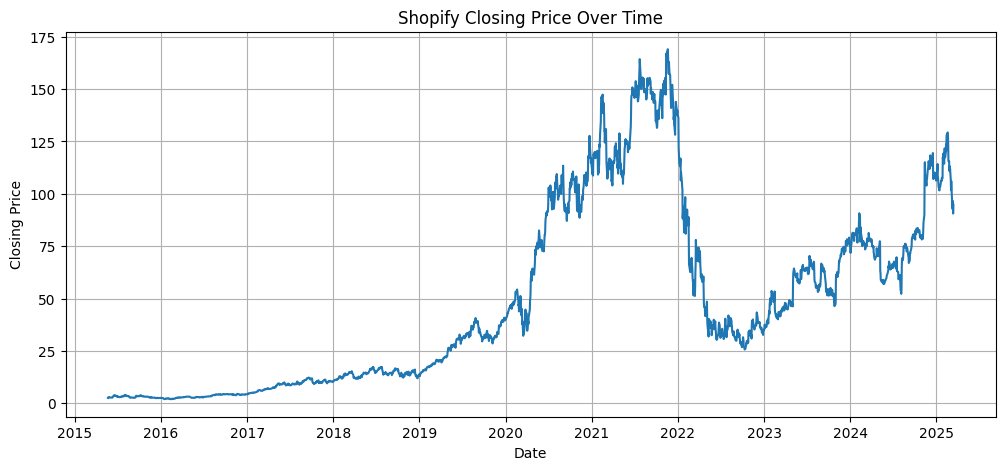

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(df["date"], df["close"])

plt.title("Shopify Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.grid(True)

plt.show()

In [9]:
df["MA20"] = df["close"].rolling(window=20).mean()
df["MA50"] = df["close"].rolling(window=50).mean()

In [10]:
plt.figure(figsize=(12, 5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

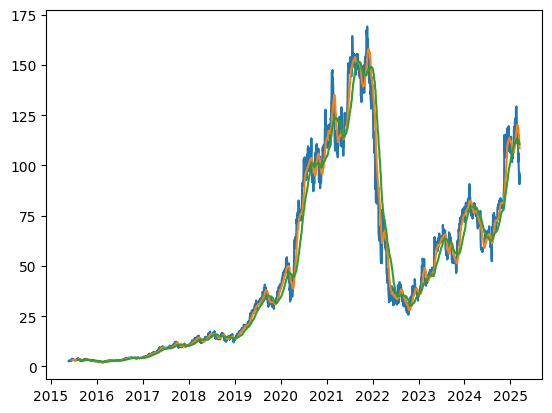

In [11]:
plt.plot(df["date"], df["close"], label="Closing Price")
plt.plot(df["date"], df["MA20"], label="20-Day Moving Average")
plt.plot(df["date"], df["MA50"], label="50-Day Moving Average")

Text(0, 0.5, 'Price')

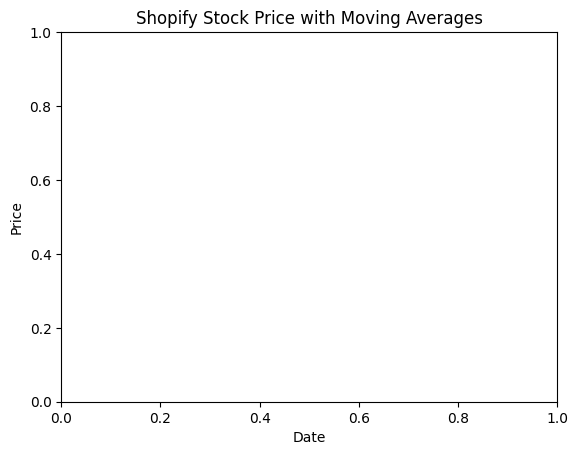

In [12]:
plt.title("Shopify Stock Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")

/tmp/ipykernel_453/1453150367.py:1: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


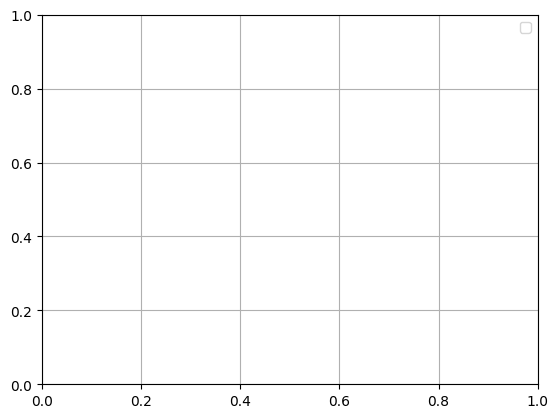

In [13]:
plt.legend()
plt.grid(True)


In [14]:
plt.show()

In [15]:
df["Daily_Return"] = df["close"].pct_change()

print(df[["date", "close", "Daily_Return"]].head(10))

                        date  close  Daily_Return
0  2015-05-21 00:00:00-04:00  2.568           NaN
1  2015-05-22 00:00:00-04:00  2.831      0.102414
2  2015-05-26 00:00:00-04:00  2.965      0.047333
3  2015-05-27 00:00:00-04:00  2.750     -0.072513
4  2015-05-28 00:00:00-04:00  2.745     -0.001818
5  2015-05-29 00:00:00-04:00  2.720     -0.009107
6  2015-06-01 00:00:00-04:00  2.733      0.004779
7  2015-06-02 00:00:00-04:00  2.695     -0.013904
8  2015-06-03 00:00:00-04:00  2.744      0.018182
9  2015-06-04 00:00:00-04:00  2.678     -0.024052


(array([  1.,   1.,   0.,   2.,   1.,   3.,   3.,   2.,   5.,   4.,   5.,
          7.,   8.,  28.,  36.,  62.,  63.,  88., 124., 189., 257., 294.,
        302., 300., 201., 152.,  95.,  70.,  41.,  32.,  26.,  18.,  10.,
          8.,   9.,   3.,   6.,   1.,   2.,   1.,   0.,   0.,   2.,   2.,
          0.,   0.,   1.,   0.,   2.,   1.]),
 array([-0.18585338, -0.17736865, -0.16888391, -0.16039917, -0.15191444,
        -0.1434297 , -0.13494497, -0.12646023, -0.1179755 , -0.10949076,
        -0.10100603, -0.09252129, -0.08403656, -0.07555182, -0.06706709,
        -0.05858235, -0.05009762, -0.04161288, -0.03312815, -0.02464341,
        -0.01615868, -0.00767394,  0.00081079,  0.00929553,  0.01778026,
         0.026265  ,  0.03474973,  0.04323447,  0.0517192 ,  0.06020394,
         0.06868867,  0.07717341,  0.08565814,  0.09414288,  0.10262761,
         0.11111235,  0.11959708,  0.12808182,  0.13656655,  0.14505129,
         0.15353602,  0.16202076,  0.17050549,  0.17899023,  0.18747496,
 

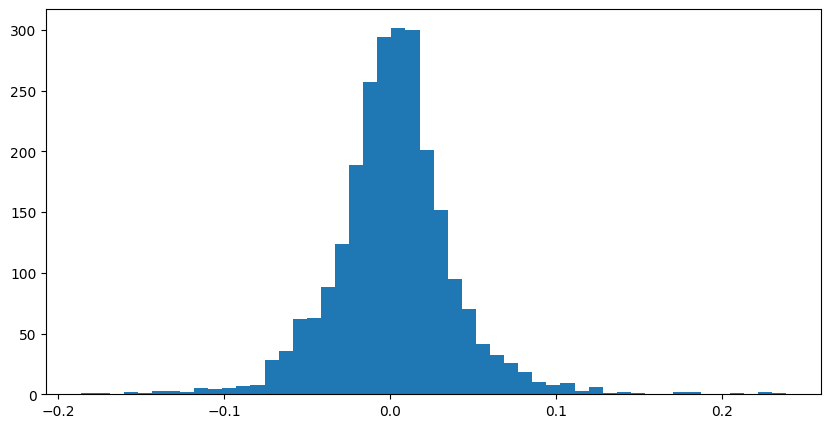

In [16]:
plt.figure(figsize=(10, 5))
plt.hist(df["Daily_Return"].dropna(), bins=50)

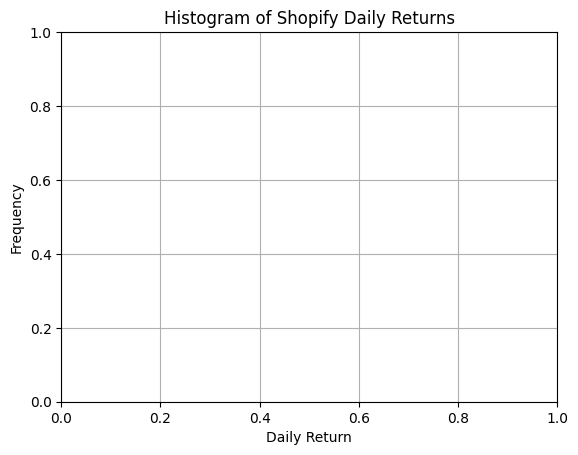

In [17]:
plt.title("Histogram of Shopify Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True)

In [18]:
plt.show()

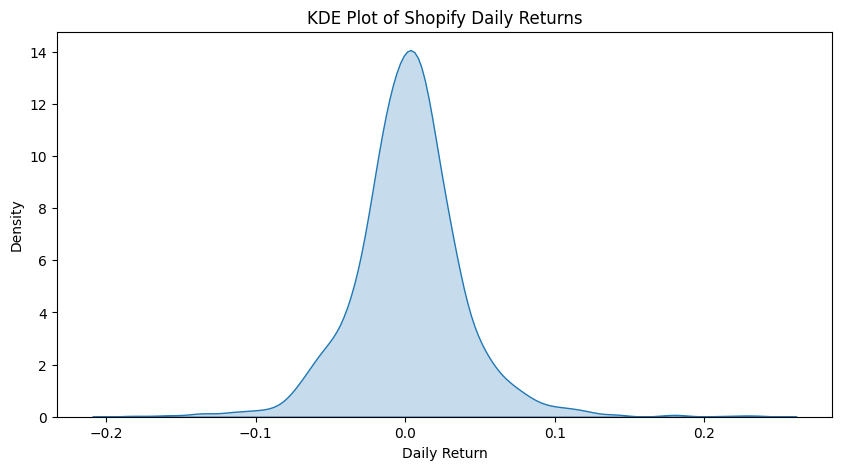

In [19]:
import seaborn as sns

plt.figure(figsize=(10, 5))

sns.kdeplot(df["Daily_Return"].dropna(), fill=True)

plt.title("KDE Plot of Shopify Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Density")

plt.show()

In [20]:
df["Rolling_Volatility"] = df["Daily_Return"].rolling(window=20).std()

In [21]:
print("FINANCIAL INSIGHTS")
print("------------------")

FINANCIAL INSIGHTS
------------------


In [22]:
start_price = df["close"].iloc[0]
end_price = df["close"].iloc[-1]

if end_price > start_price:
    print("1. Stock Price Trend: Overall upward trend.")
else:
    print("1. Stock Price Trend: Overall downward trend.")

1. Stock Price Trend: Overall upward trend.


In [23]:
volatility = df["Daily_Return"].std()

print("2. Stock Stability/Volatility:", volatility)

if volatility < 0.02:
    print("   The stock is relatively stable.")
else:
    print("   The stock is relatively volatile.")

2. Stock Stability/Volatility: 0.03712243534903455
   The stock is relatively volatile.


In [24]:
max_date = df.loc[df["Rolling_Volatility"].idxmax(), "date"]
max_volatility = df["Rolling_Volatility"].max()

print("3. High-Volatility Period:", max_date)
print("   Highest 20-day rolling volatility:", max_volatility)

3. High-Volatility Period: 2022-03-31 00:00:00-04:00
   Highest 20-day rolling volatility: 0.08336870148806906
